## 1.Data Collection..

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import pickle

In [2]:
df1=pd.read_csv('ResaleFlatPricesBasedonApprovalDate19901999.csv')
df2=pd.read_csv('ResaleFlatPricesBasedonApprovalDate2000Feb2012.csv')
df3=pd.read_csv('ResaleFlatPricesBasedonRegistrationDateFromMar2012toDec2014.csv')
df4=pd.read_csv('ResaleFlatPricesBasedonRegistrationDateFromJan2015toDec2016.csv')
df5=pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

In [3]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df5.shape)

(287196, 10)
(369651, 10)
(52203, 10)
(37153, 11)
(185506, 11)


In [4]:
df_Final=pd.concat([df1,df2])
df_Final=pd.concat([df_Final,df3])
df_Final=pd.concat([df_Final,df4])
df_Final=pd.concat([df_Final,df5])

In [5]:
#df_Final.to_csv('Singapore_Resale_Flat_Price.csv')

In [6]:
df_Copy=df_Final.copy()

## 2. Exploratory Data Analysis...

In [7]:
df_Copy.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,NaN
1,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,NaN
2,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,NaN
3,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,NaN
4,1990-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,NaN


In [8]:
df_Copy.shape

(931709, 11)

In [9]:
df_Copy.isnull().sum()

month                       0
town                        0
flat_type                   0
block                       0
street_name                 0
storey_range                0
floor_area_sqm              0
flat_model                  0
lease_commence_date         0
resale_price                0
remaining_lease        709050
dtype: int64

In [10]:
df_Copy.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price',
       'remaining_lease'],
      dtype='object')

In [11]:
df_Copy.dtypes

month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
resale_price           float64
remaining_lease         object
dtype: object

In [12]:
df_Copy['reg_month']=pd.to_datetime(df_Copy['month']).dt.month
df_Copy['reg_year']=pd.to_datetime(df_Copy['month']).dt.year

In [13]:
df_Copy=df_Copy.drop('month',axis=1)

In [65]:
df_Copy.head()

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,ANG MO KIO,1 ROOM,10 TO 12,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
1,ANG MO KIO,1 ROOM,04 TO 06,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
2,ANG MO KIO,1 ROOM,10 TO 12,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
3,ANG MO KIO,1 ROOM,07 TO 09,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
4,ANG MO KIO,3 ROOM,04 TO 06,4.290459,NEW GENERATION,1976,11.017019,1,1990,74.01198,6.535241


In [14]:
df_Copy.town.value_counts()

town
TAMPINES           80297
YISHUN             70378
JURONG WEST        67006
BEDOK              66874
WOODLANDS          65867
ANG MO KIO         52273
HOUGANG            50982
BUKIT BATOK        44709
CHOA CHU KANG      38544
BUKIT MERAH        34533
PASIR RIS          33324
SENGKANG           32820
TOA PAYOH          31680
QUEENSTOWN         28888
GEYLANG            28306
CLEMENTI           28137
BUKIT PANJANG      27827
KALLANG/WHAMPOA    27359
JURONG EAST        24870
SERANGOON          22907
BISHAN             21341
PUNGGOL            20969
SEMBAWANG          13989
MARINE PARADE       8059
CENTRAL AREA        7177
BUKIT TIMAH         2529
LIM CHU KANG          64
Name: count, dtype: int64

In [15]:
df_Copy.flat_type.unique()

array(['1 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', '2 ROOM', 'EXECUTIVE',
       'MULTI GENERATION', 'MULTI-GENERATION'], dtype=object)

In [16]:
df_Copy['flat_type']=df_Copy['flat_type'].replace('MULTI GENERATION','MULTI-GENERATION')

In [17]:
df_Copy.flat_type.unique()

array(['1 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', '2 ROOM', 'EXECUTIVE',
       'MULTI-GENERATION'], dtype=object)

In [18]:
df_Copy.block.value_counts()

block
2       4601
1       4056
110     3428
101     3412
4       3354
        ... 
460C       6
240A       4
83A        4
226E       2
226F       1
Name: count, Length: 2712, dtype: int64

In [19]:
df_Copy.flat_model.unique()

array(['IMPROVED', 'NEW GENERATION', 'MODEL A', 'STANDARD', 'SIMPLIFIED',
       'MODEL A-MAISONETTE', 'APARTMENT', 'MAISONETTE', 'TERRACE',
       '2-ROOM', 'IMPROVED-MAISONETTE', 'MULTI GENERATION',
       'PREMIUM APARTMENT', 'Improved', 'New Generation', 'Model A',
       'Standard', 'Apartment', 'Simplified', 'Model A-Maisonette',
       'Maisonette', 'Multi Generation', 'Adjoined flat',
       'Premium Apartment', 'Terrace', 'Improved-Maisonette',
       'Premium Maisonette', '2-room', 'Model A2', 'DBSS', 'Type S1',
       'Type S2', 'Premium Apartment Loft', '3Gen'], dtype=object)

In [20]:
for i in df_Copy.flat_model.unique():
        df_Copy['flat_model']=df_Copy['flat_model'].replace(i,i.upper())
print(df_Copy.flat_model.unique())

['IMPROVED' 'NEW GENERATION' 'MODEL A' 'STANDARD' 'SIMPLIFIED'
 'MODEL A-MAISONETTE' 'APARTMENT' 'MAISONETTE' 'TERRACE' '2-ROOM'
 'IMPROVED-MAISONETTE' 'MULTI GENERATION' 'PREMIUM APARTMENT'
 'ADJOINED FLAT' 'PREMIUM MAISONETTE' 'MODEL A2' 'DBSS' 'TYPE S1'
 'TYPE S2' 'PREMIUM APARTMENT LOFT' '3GEN']


In [21]:
df_Copy['lease_commence_date']=pd.to_datetime(df_Copy['lease_commence_date'],format='%Y').dt.year

In [22]:
df_Copy.dtypes

town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int32
resale_price           float64
remaining_lease         object
reg_month                int32
reg_year                 int32
dtype: object

In [66]:
df_Copy.remaining_lease_year.unique()

array([74.01198006, 61.        , 60.        , 62.        , 58.        ,
       59.        , 63.        , 93.        , 94.        , 78.        ,
       70.        , 67.        , 68.        , 66.        , 65.        ,
       69.        , 64.        , 87.        , 71.        , 92.        ,
       54.        , 82.        , 75.        , 55.        , 74.        ,
       72.        , 86.        , 79.        , 53.        , 57.        ,
       51.        , 56.        , 95.        , 52.        , 90.        ,
       81.        , 80.        , 83.        , 84.        , 77.        ,
       85.        , 88.        , 50.        , 73.        , 48.        ,
       89.        , 91.        , 49.        , 76.        , 96.        ,
       47.        , 46.        , 45.        , 97.        , 44.        ,
       43.        , 42.        , 41.        ])

In [23]:
df_Copy[['remaining_lease_year','remaining_lease_month']]=df_Copy['remaining_lease'].str.extract(r'(\d+) years (\d+) months')
df_Copy['remaining_lease_year'] = pd.to_numeric(df_Copy['remaining_lease_year'])
df_Copy['remaining_lease_month'] = pd.to_numeric(df_Copy['remaining_lease_month'])
df_Copy['remaining_lease_year'].fillna(df_Copy['remaining_lease_year'].mean(),inplace=True)
df_Copy['remaining_lease_month'].fillna(df_Copy['remaining_lease_month'].mean(),inplace=True)


C:\Users\Kobalan M\AppData\Local\Temp\ipykernel_14520\236046419.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_Copy['remaining_lease_year'].fillna(df_Copy['remaining_lease_year'].mean(),inplace=True)
C:\Users\Kobalan M\AppData\Local\Temp\ipykernel_14520\236046419.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

In [68]:
df_Copy.isnull().sum()

town                     0
flat_type                0
storey_range             0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
reg_month                0
reg_year                 0
remaining_lease_year     0
remaining_lease_month    0
dtype: int64

In [24]:
df_Copy.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,NaN,1,1990,74.01198,6.535241
1,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,NaN,1,1990,74.01198,6.535241
2,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,NaN,1,1990,74.01198,6.535241
3,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,NaN,1,1990,74.01198,6.535241
4,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,NaN,1,1990,74.01198,6.535241


In [25]:
df_Copy=df_Copy.drop(['block','street_name','remaining_lease'],axis=1)

<Axes: xlabel='lease_commence_date', ylabel='resale_price'>

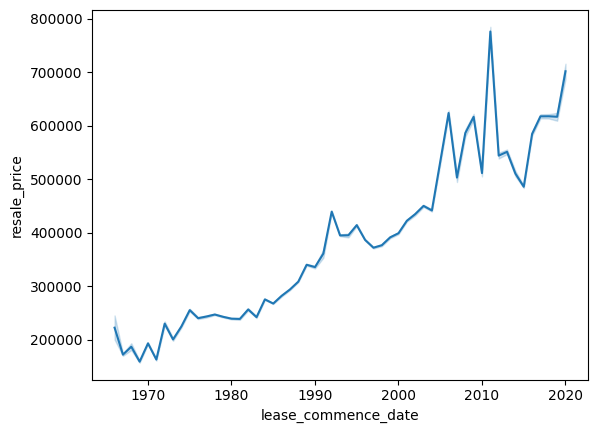

In [26]:
sns.lineplot(data=df_Copy,x='lease_commence_date',y='resale_price')

<Axes: xlabel='reg_year', ylabel='resale_price'>

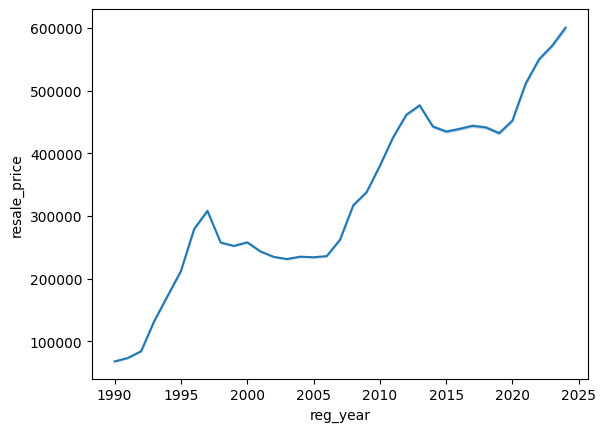

In [27]:
sns.lineplot(data=df_Copy,x='reg_year',y='resale_price')

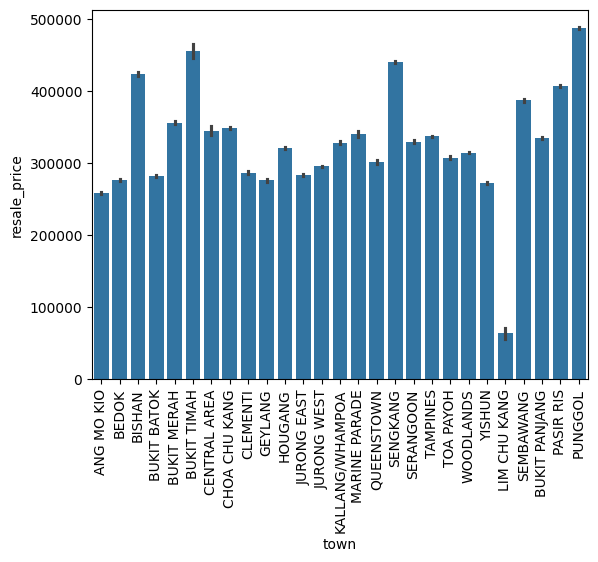

In [28]:
sns.barplot(data=df_Copy,x='town',y='resale_price')
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='resale_price', ylabel='floor_area_sqm'>

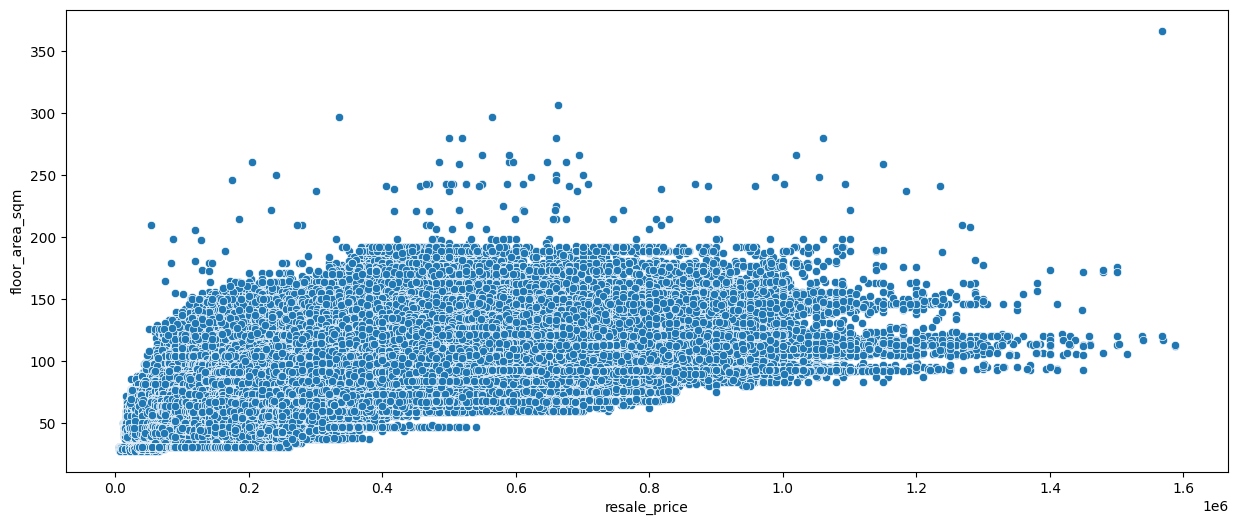

In [29]:
plt.figure(figsize=(15,6))
sns.scatterplot(x = 'resale_price' ,y = 'floor_area_sqm',data = df_Copy)

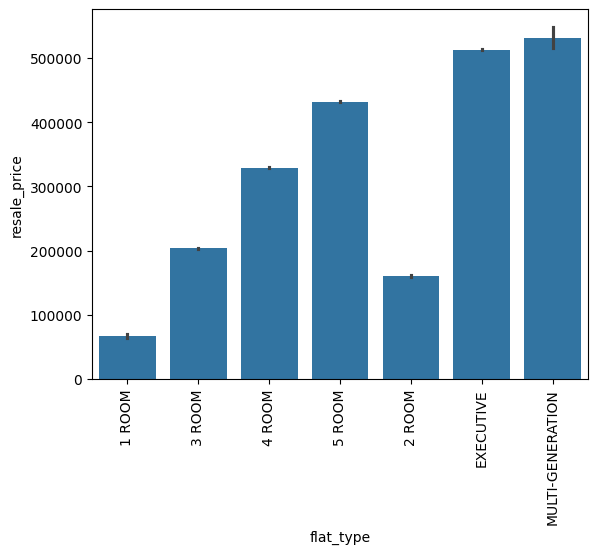

In [30]:
sns.barplot(data=df_Copy,x='flat_type',y='resale_price')
plt.xticks(rotation='vertical')
plt.show()

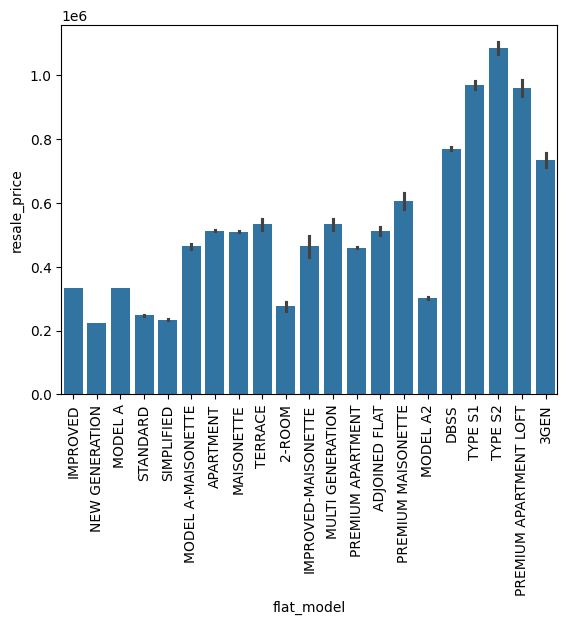

In [31]:
sns.barplot(data=df_Copy,x='flat_model',y='resale_price')
plt.xticks(rotation='vertical')
plt.show()

In [32]:
# find outliers - box plot & skewed data - hist plot and violin plot

def plot(df, column):
    plt.figure(figsize=(20,5))
    plt.subplot(1,3,1)
    sns.boxplot(data=df, x=column)
    plt.title(f'Box Plot for {column}')

    plt.subplot(1,3,2)
    sns.histplot(data=df, x=column, kde=True, bins=50)
    plt.title(f'Distribution Plot for {column}')

    plt.subplot(1,3,3)
    sns.violinplot(data=df, x=column)
    plt.title(f'Violin Plot for {column}')
    plt.show()

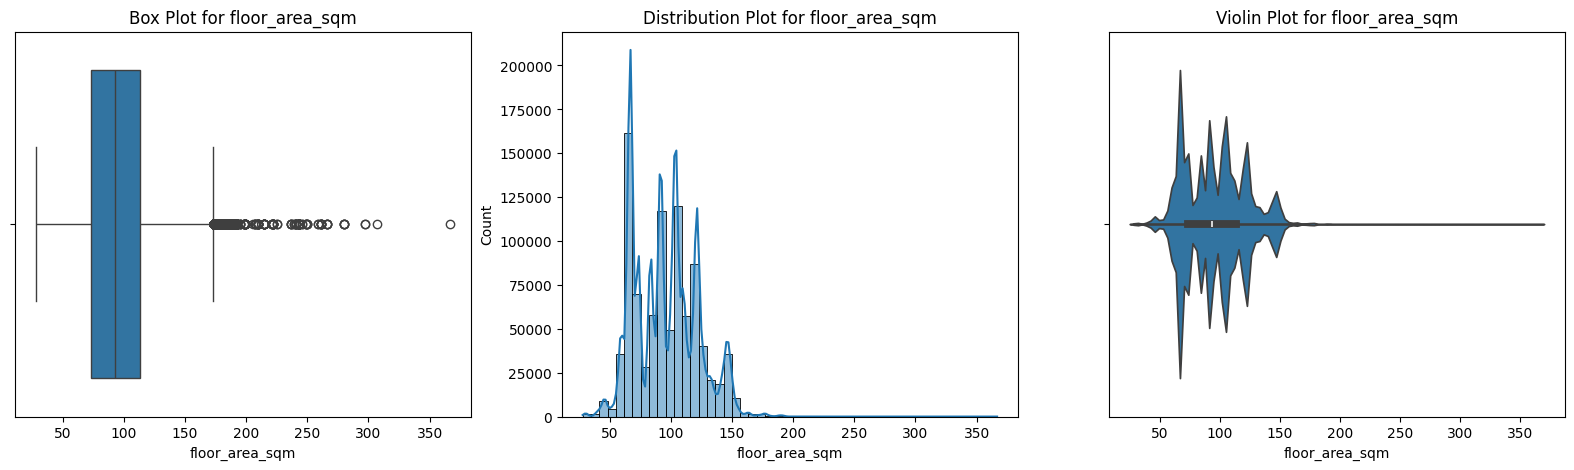

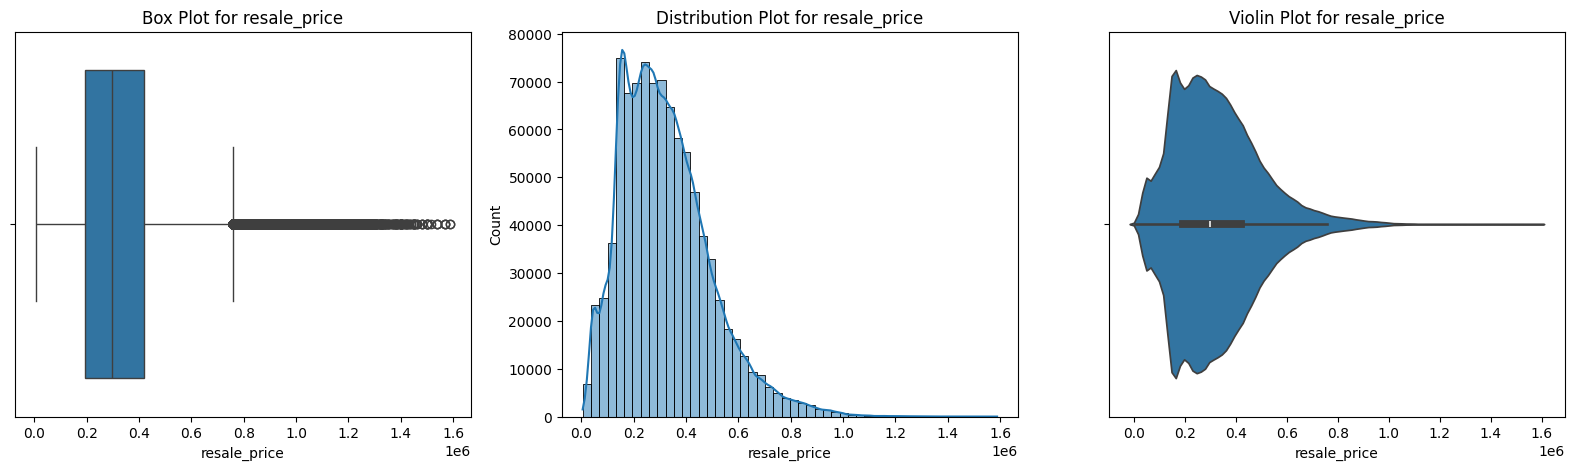

In [33]:
columns=['floor_area_sqm','resale_price']
for i in columns:
    plot(df_Copy,i)

In [34]:
df_Copy['floor_area_sqm']=np.log(df_Copy['floor_area_sqm'])
df_Copy['resale_price']=np.log(df_Copy['resale_price'])

In [35]:
df_Copy.head(3)

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,ANG MO KIO,1 ROOM,10 TO 12,3.433987,IMPROVED,1977,9.104980,1,1990,74.01198,6.535241
1,ANG MO KIO,1 ROOM,04 TO 06,3.433987,IMPROVED,1977,8.699515,1,1990,74.01198,6.535241
2,ANG MO KIO,1 ROOM,10 TO 12,3.433987,IMPROVED,1977,8.987197,1,1990,74.01198,6.535241


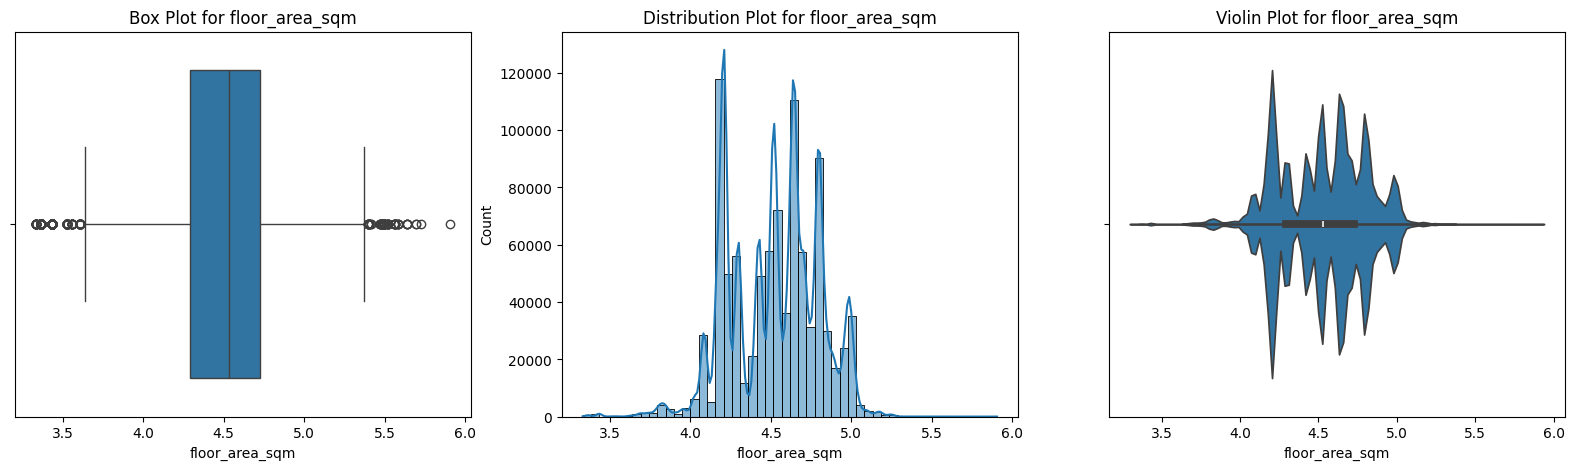

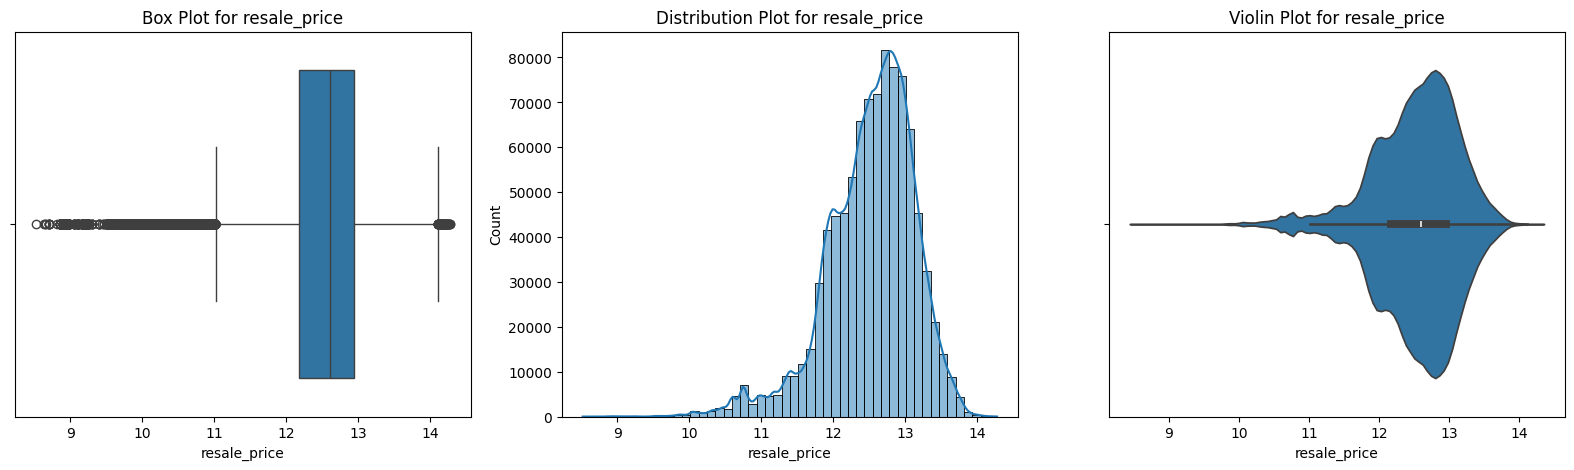

In [36]:
columns=['floor_area_sqm','resale_price']
for i in columns:
    plot(df_Copy,i)

In [37]:

def outlier(df, column):
    iqr = df[column].quantile(0.75) - df[column].quantile(0.25)
    upper_threshold = df[column].quantile(0.75) + (1.5*iqr)
    lower_threshold = df[column].quantile(0.25) - (1.5*iqr)
    df[column] = df[column].clip(lower_threshold, upper_threshold)
    dict_VALUE={'IQR':iqr,'UPPER_TH':upper_threshold,'LOWER_TH':lower_threshold}
    return dict_VALUE

print(outlier(df_Copy,'floor_area_sqm'))
print(outlier(df_Copy,'resale_price'))


{'IQR': 0.43692837756394987, 'UPPER_TH': 5.382780385058266, 'LOWER_TH': 3.635066874802466}
{'IQR': 0.7723965522140865, 'UPPER_TH': 14.106604818580681, 'LOWER_TH': 11.017018609724335}


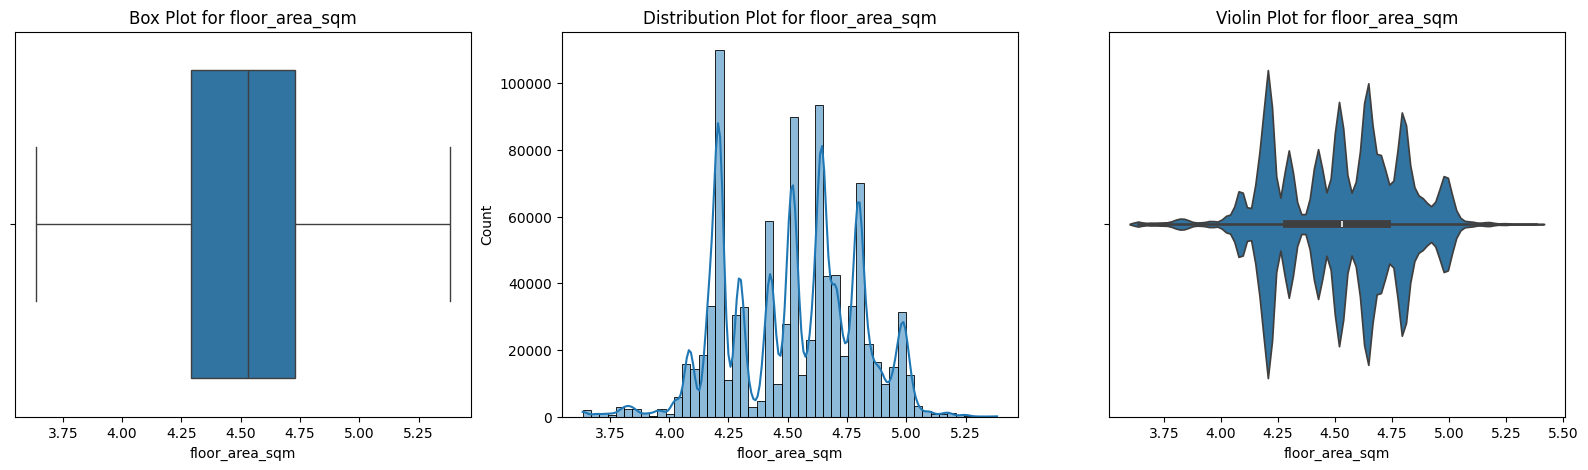

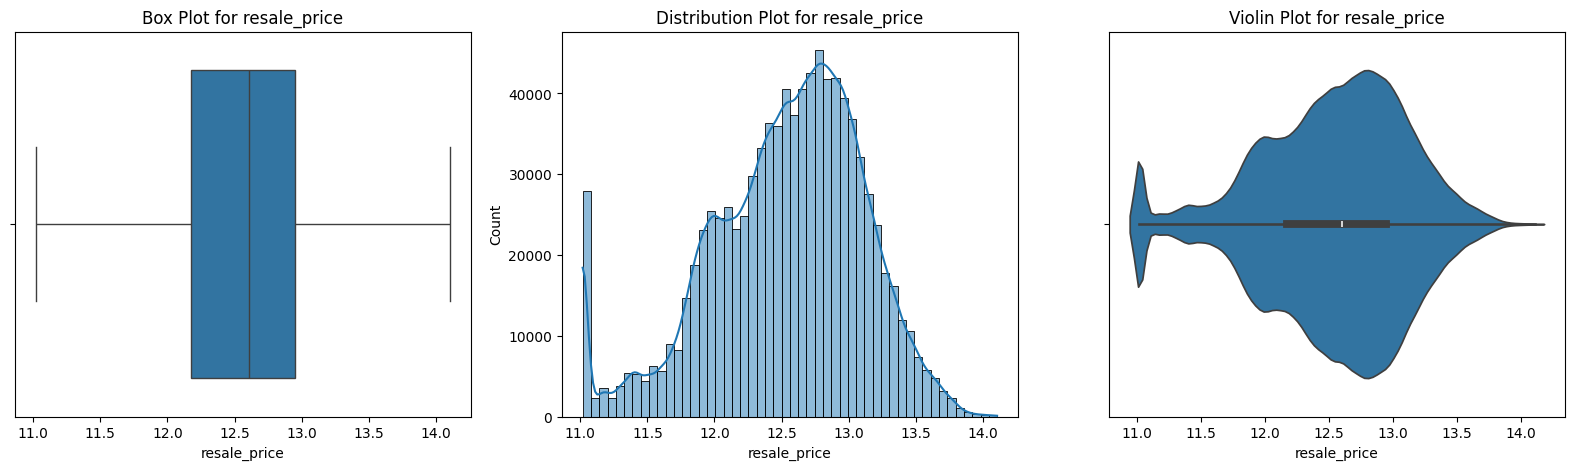

In [38]:
columns=['floor_area_sqm','resale_price']
for i in columns:
    plot(df_Copy,i)

In [39]:
df_Copy.head(2)

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,ANG MO KIO,1 ROOM,10 TO 12,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
1,ANG MO KIO,1 ROOM,04 TO 06,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241


In [164]:
df2=df_Copy.copy()

In [165]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df2['town']=label_encoder.fit_transform(df2['town'])
df2['storey_range']=label_encoder.fit_transform(df2['storey_range'])
df2['flat_type']=label_encoder.fit_transform(df2['flat_type'])
df2['flat_model']=label_encoder.fit_transform(df2['flat_model'])


In [166]:
df2.dtypes

town                       int32
flat_type                  int32
storey_range               int32
floor_area_sqm           float64
flat_model                 int32
lease_commence_date        int32
resale_price             float64
reg_month                  int32
reg_year                   int32
remaining_lease_year     float64
remaining_lease_month    float64
dtype: object

In [167]:
dict_TOWN=dict(zip(df_Copy.town.unique(),df2.town.unique()))
dict_TOWN

{'ANG MO KIO': 0,
 'BEDOK': 1,
 'BISHAN': 2,
 'BUKIT BATOK': 3,
 'BUKIT MERAH': 4,
 'BUKIT TIMAH': 6,
 'CENTRAL AREA': 7,
 'CHOA CHU KANG': 8,
 'CLEMENTI': 9,
 'GEYLANG': 10,
 'HOUGANG': 11,
 'JURONG EAST': 12,
 'JURONG WEST': 13,
 'KALLANG/WHAMPOA': 14,
 'MARINE PARADE': 16,
 'QUEENSTOWN': 19,
 'SENGKANG': 21,
 'SERANGOON': 22,
 'TAMPINES': 23,
 'TOA PAYOH': 24,
 'WOODLANDS': 25,
 'YISHUN': 26,
 'LIM CHU KANG': 15,
 'SEMBAWANG': 20,
 'BUKIT PANJANG': 5,
 'PASIR RIS': 17,
 'PUNGGOL': 18}

In [168]:
dict_STOREY=dict(zip(df_Copy.storey_range.unique(),df2.storey_range.unique()))
dict_STOREY

{'10 TO 12': 5,
 '04 TO 06': 2,
 '07 TO 09': 4,
 '01 TO 03': 0,
 '13 TO 15': 7,
 '19 TO 21': 10,
 '16 TO 18': 8,
 '25 TO 27': 13,
 '22 TO 24': 12,
 '28 TO 30': 15,
 '31 TO 33': 16,
 '40 TO 42': 21,
 '37 TO 39': 20,
 '34 TO 36': 18,
 '06 TO 10': 3,
 '01 TO 05': 1,
 '11 TO 15': 6,
 '16 TO 20': 9,
 '21 TO 25': 11,
 '26 TO 30': 14,
 '36 TO 40': 19,
 '31 TO 35': 17,
 '46 TO 48': 23,
 '43 TO 45': 22,
 '49 TO 51': 24}

In [169]:
dict_FlatMODEL=dict(zip(df_Copy.flat_model.unique(),df2.flat_model.unique()))
dict_FlatMODEL

{'IMPROVED': 5,
 'NEW GENERATION': 12,
 'MODEL A': 8,
 'STANDARD': 17,
 'SIMPLIFIED': 16,
 'MODEL A-MAISONETTE': 9,
 'APARTMENT': 3,
 'MAISONETTE': 7,
 'TERRACE': 18,
 '2-ROOM': 0,
 'IMPROVED-MAISONETTE': 6,
 'MULTI GENERATION': 11,
 'PREMIUM APARTMENT': 13,
 'ADJOINED FLAT': 2,
 'PREMIUM MAISONETTE': 15,
 'MODEL A2': 10,
 'DBSS': 4,
 'TYPE S1': 19,
 'TYPE S2': 20,
 'PREMIUM APARTMENT LOFT': 14,
 '3GEN': 1}

In [170]:
dict_FlatTYPE=dict(zip(df_Copy.flat_type.unique(),df2.flat_type.unique()))
dict_FlatTYPE

{'1 ROOM': 0,
 '3 ROOM': 2,
 '4 ROOM': 3,
 '5 ROOM': 4,
 '2 ROOM': 1,
 'EXECUTIVE': 5,
 'MULTI-GENERATION': 6}

In [171]:
df2.isnull().sum()

town                     0
flat_type                0
storey_range             0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
reg_month                0
reg_year                 0
remaining_lease_year     0
remaining_lease_month    0
dtype: int64

In [48]:
# import json

# with open('town.json','w') as File:
#     json.dump(dict_TOWN,File)

# with open('storey_range.json','w') as File:
#     json.dump(dict_STOREY,File)

# with open('flat_type.json','w') as File:
#     json.dump(dict_FlatTYPE,File)

# with open('flat_model.json','w') as File:
#     json.dump(dict_FlatMODEL,File)

In [172]:
df2.head()

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,0,0,5,3.635067,5,1977,11.017019,1,1990,74.01198,6.535241
1,0,0,2,3.635067,5,1977,11.017019,1,1990,74.01198,6.535241
2,0,0,5,3.635067,5,1977,11.017019,1,1990,74.01198,6.535241
3,0,0,4,3.635067,5,1977,11.017019,1,1990,74.01198,6.535241
4,0,2,2,4.290459,12,1976,11.017019,1,1990,74.01198,6.535241


In [173]:
df_Copy.dtypes

town                      object
flat_type                 object
storey_range              object
floor_area_sqm           float64
flat_model                object
lease_commence_date        int32
resale_price             float64
reg_month                  int32
reg_year                   int32
remaining_lease_year     float64
remaining_lease_month    float64
dtype: object

In [174]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
numerical_COLUMNS=['floor_area_sqm','lease_commence_date','reg_month','reg_year','remaining_lease_month','remaining_lease_year']
df2[numerical_COLUMNS]=scaler.fit_transform(df2[numerical_COLUMNS])
df2.head()

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,0,0,5,-3.231455,5,-1.057152,11.017019,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
1,0,0,2,-3.231455,5,-1.057152,11.017019,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
2,0,0,5,-3.231455,5,-1.057152,11.017019,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
3,0,0,4,-3.231455,5,-1.057152,11.017019,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
4,0,2,2,-0.849337,12,-1.150501,11.017019,-1.629982,-1.732891,4.991183e-15,-4.523321e-15


In [175]:
df_Corr1=df2.corr()['resale_price']
df_Corr1

town                     0.084125
flat_type                0.600562
storey_range             0.187734
floor_area_sqm           0.597107
flat_model              -0.260712
lease_commence_date      0.535660
resale_price             1.000000
reg_month                0.009731
reg_year                 0.691289
remaining_lease_year     0.085247
remaining_lease_month    0.001337
Name: resale_price, dtype: float64

<Axes: >

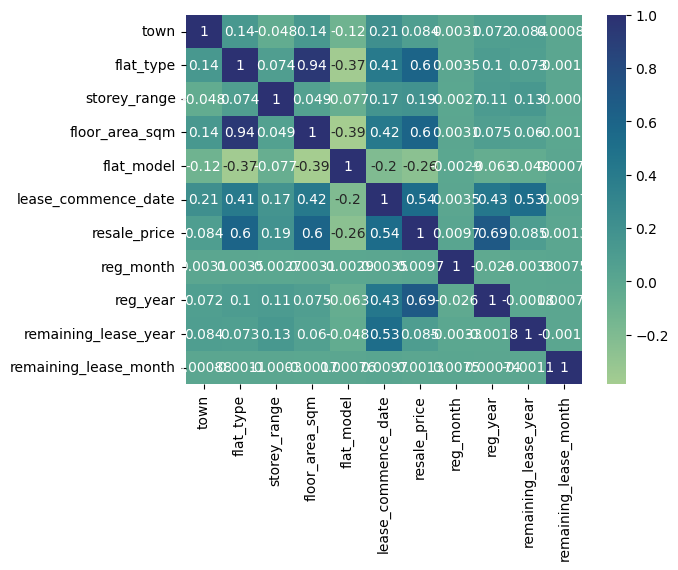

In [176]:
df_Corr=df2.corr()
sns.heatmap(df_Corr,cmap='crest',annot=True)


In [180]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


x = df2.drop(columns=['resale_price','flat_type'],axis=1)
y = df2['resale_price']


vif_data = pd.DataFrame()
vif_data["feature"] = x.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

print(vif_data)


                 feature       VIF
0                   town  2.635416
1           storey_range  2.217150
2         floor_area_sqm  1.407851
3             flat_model  3.279809
4    lease_commence_date  2.516876
5              reg_month  1.001279
6               reg_year  1.421972
7   remaining_lease_year  1.647836
8  remaining_lease_month  1.000337


In [182]:
x

,town,storey_range,floor_area_sqm,flat_model,lease_commence_date,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,0,5,-3.231455,5,-1.057152,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
1,0,2,-3.231455,5,-1.057152,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
2,0,5,-3.231455,5,-1.057152,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
3,0,4,-3.231455,5,-1.057152,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
4,0,2,-0.849337,12,-1.150501,-1.629982,-1.732891,4.991183e-15,-4.523321e-15
...,...,...,...,...,...,...,...,...,...
185501,26,2,1.670005,7,-0.030318,0.131933,1.891604,4.991183e-15,-4.523321e-15
185502,26,5,1.645025,3,-0.030318,0.131933,1.891604,4.991183e-15,-4.523321e-15
185503,26,0,1.670005,7,-0.310364,0.131933,1.891604,-2.460667e+00,-3.000716e+00
185504,26,2,1.670005,7,-0.310364,0.131933,1.891604,-2.460667e+00,-3.849517e+00


In [179]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor


# x = df2.drop(columns=['resale_price','floor_area_sqm'],axis=1)
# y = df2['resale_price']


# vif_data = pd.DataFrame()
# vif_data["feature"] = x.columns

# # calculating VIF for each feature
# vif_data["VIF"] = [variance_inflation_factor(x.values, i)
#                           for i in range(len(x.columns))]

# print(vif_data)


                 feature       VIF
0                   town  3.273983
1              flat_type  5.943781
2           storey_range  2.560391
3             flat_model  4.086750
4    lease_commence_date  2.194836
5              reg_month  1.001241
6               reg_year  1.384420
7   remaining_lease_year  1.592134
8  remaining_lease_month  1.000287


In [149]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor



def machine_algorithm(df,algorithm):
        
    x = df.drop(columns=['resale_price','flat_type'], axis=1)
    y = df['resale_price']

    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    
    model = algorithm().fit(x_train, y_train)
#  y_pred = model.predict(x_train)
#  y_pred= model.predict(x_test)
#  r2_train = r2_score(y_train, y_pred_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    r2_train = r2_score(y_train,y_pred_train)
    r2_test = r2_score(y_test,y_pred_test)
    mse_Value=mean_squared_error(y_test,y_pred_test)
    accuracy_value={'r2_train':r2_train,'r2_test':r2_test,'mse':mse_Value}
    return accuracy_value    

In [150]:
print(machine_algorithm(df2, LinearRegression))
print(machine_algorithm(df2, DecisionTreeRegressor))
print(machine_algorithm(df2, RandomForestRegressor))
print(machine_algorithm(df2,AdaBoostRegressor))
print(machine_algorithm(df2,XGBRegressor))

{'r2_train': 0.7892530002481487, 'r2_test': 0.7888092138139412, 'mse': 0.07090346759300072}
{'r2_train': 0.9979945137831812, 'r2_test': 0.9693205321521925, 'mse': 0.010300073661362784}
{'r2_train': 0.9959696999022155, 'r2_test': 0.9813092724192305, 'mse': 0.0062750720391047945}
{'r2_train': 0.8458582182661671, 'r2_test': 0.8459114531125032, 'mse': 0.05173242871052589}
{'r2_train': 0.980173363972461, 'r2_test': 0.9798783108654853, 'mse': 0.006755491369820384}


In [55]:
# x = df2.drop(columns=['resale_price'], axis=1)
# y = df2['resale_price']
# Scaler=StandardScaler()
# X=Scaler.fit_transform(x)
# x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# param_grid_r = {'max_depth': [2, 5, 10, 20],
#               'min_samples_split': [2, 5, 10],
#               'min_samples_leaf' : [1, 2, 4],
#               'max_features'     : ['sqrt', 'log2', None]}

# grid_search_r = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=param_grid_r, cv=5)
# grid_search_r.fit(x_train, y_train)
# print(grid_search_r.best_params_)

# print(grid_search_r.best_score_)

In [183]:
x = df2.drop(columns=['resale_price','flat_type'], axis=1)
y = df2['resale_price']
# Scaler=StandardScaler()
# X=Scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x ,y,test_size=0.2,random_state=42)

model = DecisionTreeRegressor(max_depth=20, max_features=None, min_samples_leaf=4, min_samples_split=10)
model.fit(x_train, y_train)
y_pred_train=model.predict(x_train)
y_pred_test = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_train=r2_score(y_train,y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
metrics_r = {'R2_TRAIN': r2_train,
             'R2_TEST':r2_test,

           'Mean Squared Error': mse,
           'Root Mean Squared Error': rmse}

metrics_r

{'R2_TRAIN': 0.9832579865322618,
 'R2_TEST': 0.9752873437707305,
 'Mean Squared Error': 0.00829682512070049,
 'Root Mean Squared Error': 0.09108690971100343}

In [85]:
# with open('model.pkl', 'wb') as f:
#     pickle.dump(model, f)

In [194]:
import json

with open('town.json') as File1:
    town_DICT=json.load(File1)
with open('flat_type.json') as File2:
    flat_type_DICT=json.load(File2)
with open('storey_range.json') as File3:
    storey_range_DICT=json.load(File3)
with open('flat_model.json') as File4:
    flat_model_DICT=json.load(File4)

# with open(r'model.pkl', 'rb') as f:
#     DTR_model = pickle.load(f)

town="ANG MO KIO"
flat_type="1 ROOM"
storey_range="10 TO 12"
floor_area_sqm=55.2
flat_model="NEW GENERATION"
lease_commence_date=1994
reg_month=1
reg_year=1990
remaining_lease_year=20
remaining_lease_month=3

# make array for all user input values in required order for model prediction
user_data = np.array([[town_DICT[town],storey_range_DICT[storey_range],floor_area_sqm,flat_model_DICT[flat_model],lease_commence_date,reg_month,reg_year,remaining_lease_year,remaining_lease_month]])
print(user_data)
# scaled_user_data=Scaler.fit_transform(user_data)  ,flat_type_DICT[flat_type]

[[0.000e+00 5.000e+00 5.520e+01 1.200e+01 1.994e+03 1.000e+00 1.990e+03
  2.000e+01 3.000e+00]]


In [195]:
#model predict the selling price based on user input
user_data1 = np.array([[4, 3, 2, 4.785069, 4, 2023, 3, 1989, 69.000000, 4.000000]])

y_pred = model.predict(user_data)

# inverse transformation for log transformation data
price = np.exp(y_pred[0])
print(price)

1111967.4116413398


c:\Users\Kobalan M\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [187]:
df_Copy.head()

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,reg_month,reg_year,remaining_lease_year,remaining_lease_month
0,ANG MO KIO,1 ROOM,10 TO 12,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
1,ANG MO KIO,1 ROOM,04 TO 06,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
2,ANG MO KIO,1 ROOM,10 TO 12,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
3,ANG MO KIO,1 ROOM,07 TO 09,3.635067,IMPROVED,1977,11.017019,1,1990,74.01198,6.535241
4,ANG MO KIO,3 ROOM,04 TO 06,4.290459,NEW GENERATION,1976,11.017019,1,1990,74.01198,6.535241
